In [1]:
import pandas as pd
from src.base import *
from utils.functions import *

In [2]:
data = pd.read_csv("data/streamlit_sample_data.csv").set_index("sample_name")
metadata = pd.read_csv('data/streamlit_sample_metadata.csv').set_index('sample_name')
data = data.loc[metadata['batch']<=2,:]
metadata = metadata.loc[data.index,:]

Initailzing Models
Computing Correlation Matrix [1/2]
Selecting Top Correlated Features: [1/2]
Computing Correlation Matrix [2/2]
Selecting Top Correlated Features: [2/2]
Normalizing All batches


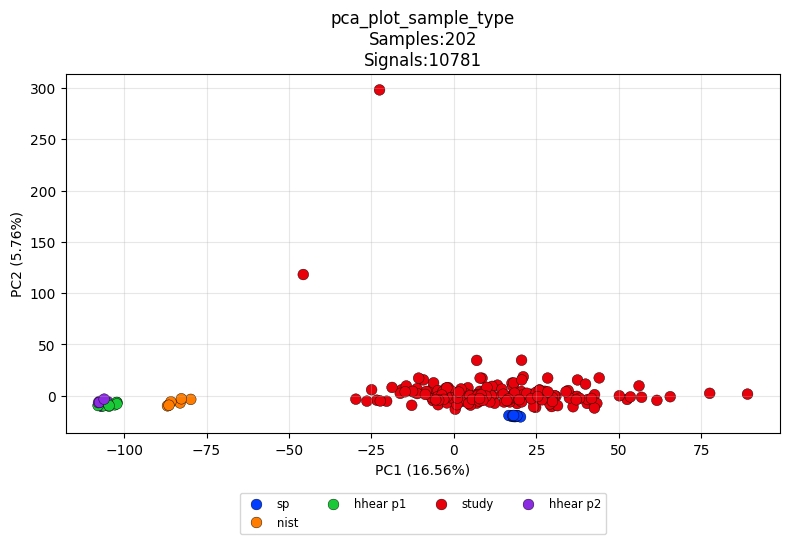

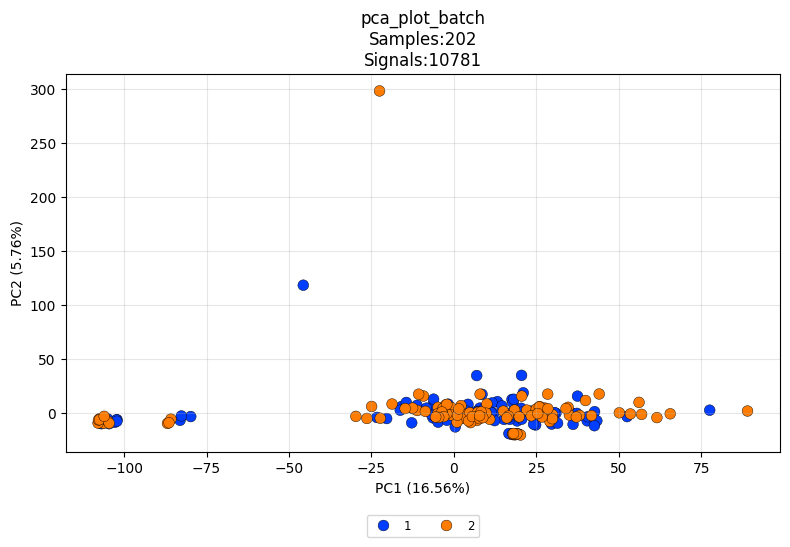

In [3]:
pipeline = BatchCorrectionPipeline(
    method=SERRF(qc_str='SP',blank_str='BLANK'),
    preprocessing_config=Preprocessor(imputation_method="Global Minimum Value",log_transform=False)
)
results = pipeline.correct(data=data,metadata=metadata)
df = pca_plot(results,metadata,hues=['sample_type','batch'],blank_str='_BLANK_',savefig=False)

Applying MetNormalizer Correction
Found 18 QC samples and 184 biological samples across 2 Batches
Computing Correlated Features
Selecting Top Correlated Features
Normalizing Signals


100%|██████████████████████████████████| 10781/10781 [00:02<00:00, 4844.04it/s]


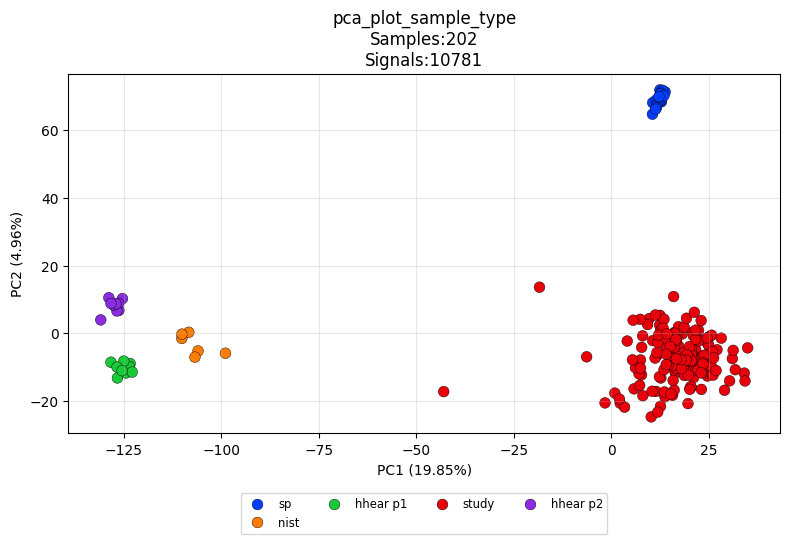

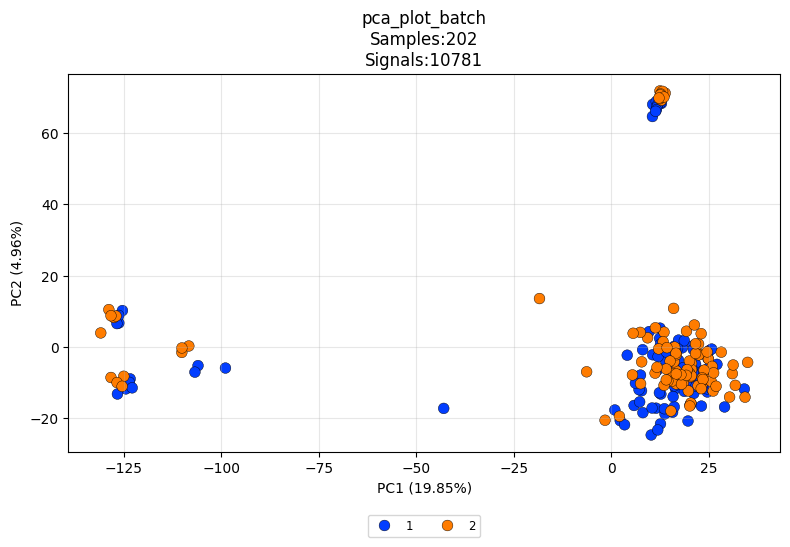

In [8]:
pipeline = BatchCorrectionPipeline(
    method=MetNormalizer(qc_str='SP',blank_str='BLANK'),
    preprocessing_config=Preprocessor(imputation_method="Global Minimum Value",log_transform=True)
)
results = pipeline.correct(data=data,metadata=metadata)
df = pca_plot(results,metadata,hues=['sample_type','batch'],blank_str='_BLANK_',savefig=False)

[INFO] Found 2 batches
[INFO] Adjusting for 0 covariate(s) or covariate level(s)
[INFO] Standardizing Data across genes.


[INFO] Fitting L/S model and finding priors.
[INFO] Finding parametric adjustments.
[INFO] Adjusting the Data


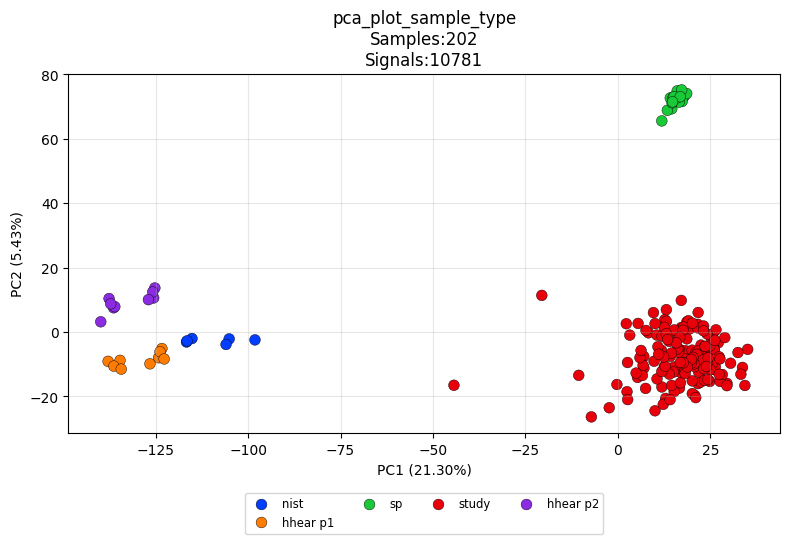

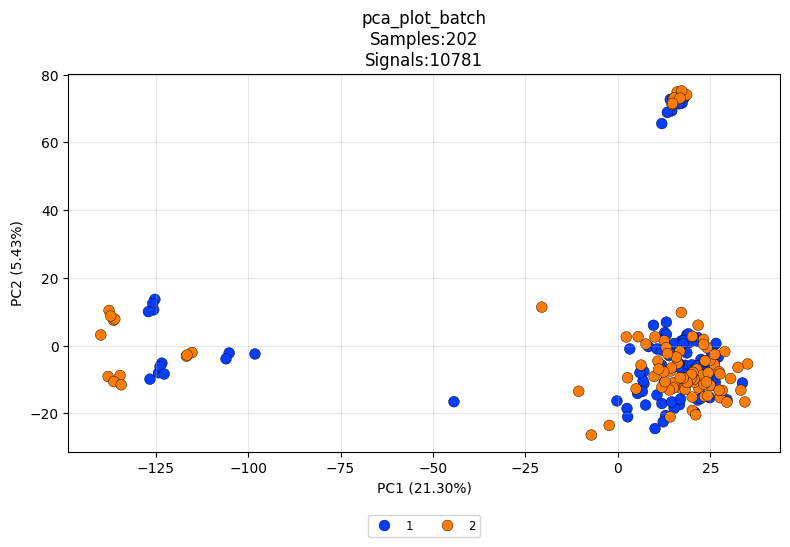

In [5]:
pipeline = BatchCorrectionPipeline(
    method=Combat(qc_str='SP',blank_str='BLANK'),
    preprocessing_config=Preprocessor(imputation_method="Global Minimum Value",log_transform=True)
)
results = pipeline.correct(data=data,metadata=metadata)

df = pca_plot(results,metadata,hues=['sample_type','batch'],blank_str='_BLANK_',savefig=False)

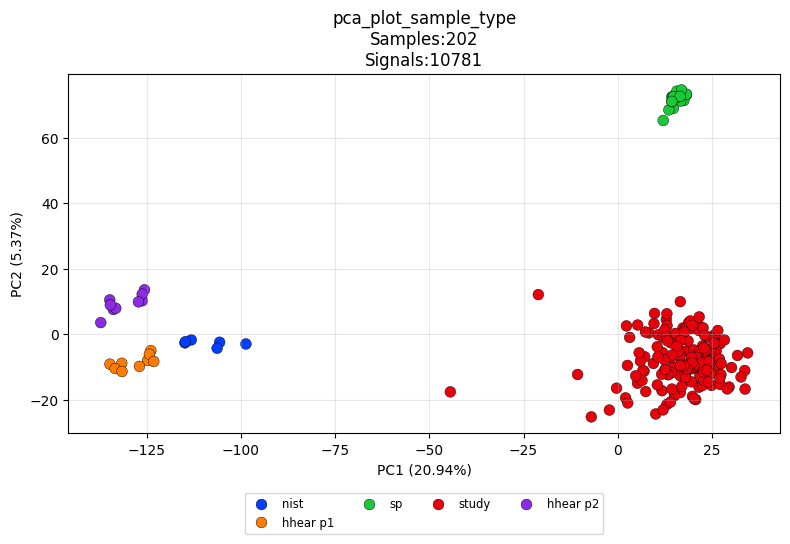

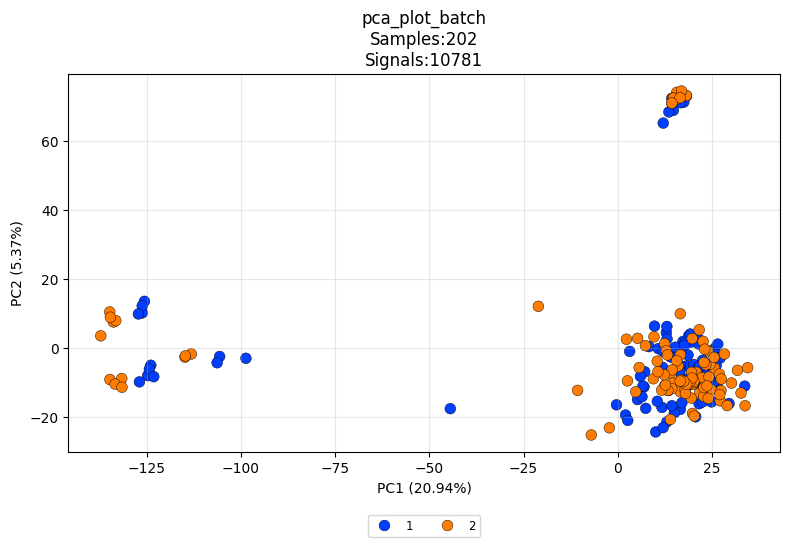

In [7]:
pipeline = BatchCorrectionPipeline(
    method=Limma(qc_str='SP',blank_str='B',covariates=['batch']),
    preprocessing_config=Preprocessor(imputation_method="Global Minimum Value",log_transform=True)
)
results = pipeline.correct(data=data,metadata=metadata)
df = pca_plot(results,metadata,hues=['sample_type','batch'],blank_str='_BLANK_',savefig=False)